### Score improvements decrease after several attempts (learning plateaus over time).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

q1 = pd.read_csv("/content/drive/MyDrive/dataset/marks/quiz1/quiz1_marks.csv")
q2 = pd.read_csv("/content/drive/MyDrive/dataset/marks/quiz2/quiz2_marks.csv")
q3 = pd.read_csv("/content/drive/MyDrive/dataset/marks/quiz3/quiz3_marks.csv")


In [3]:
q1['Quiz'] = 'Quiz1'
q2['Quiz'] = 'Quiz2'
q3['Quiz'] = 'Quiz3'

In [4]:
df = pd.concat([q1, q2, q3], ignore_index=True)

In [5]:
df['Grade/10.00'] = pd.to_numeric(df['Grade/10.00'], errors='coerce')
df['Q. 1 /2.00'] = pd.to_numeric(df['Q. 1 /2.00'], errors='coerce')
df['Q. 2 /2.00'] = pd.to_numeric(df['Q. 2 /2.00'], errors='coerce')
df['Q. 3 /2.00'] = pd.to_numeric(df['Q. 3 /2.00'], errors='coerce')
df['Q. 4 /2.00'] = pd.to_numeric(df['Q. 4 /2.00'], errors='coerce')
df['Q. 5 /2.00'] = pd.to_numeric(df['Q. 5 /2.00'], errors='coerce')

In [6]:
import pandas as pd

# Convert time column
df['Started on'] = pd.to_datetime(df['Started on'])

# Sort values to get correct attempt order
df = df.sort_values(by=['Student Code', 'Quiz', 'Started on'])

# Create attempt number per student per quiz
df['Attempt'] = df.groupby(['Student Code', 'Quiz']).cumcount() + 1

In [7]:
# Remove null grades
df_clean = df.dropna(subset=['Grade/10.00'])



In [8]:
avg_scores = df_clean.groupby('Attempt')['Grade/10.00'].mean().reset_index()

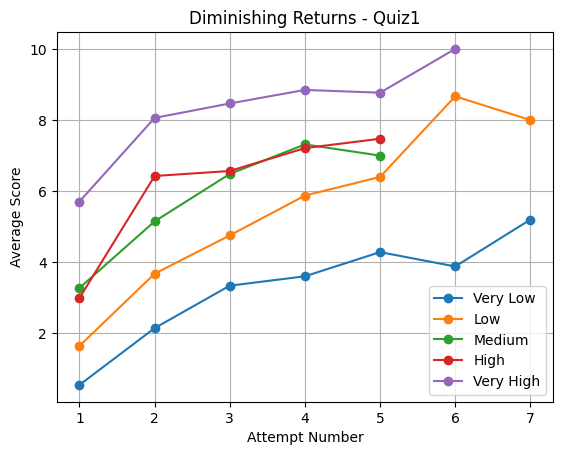

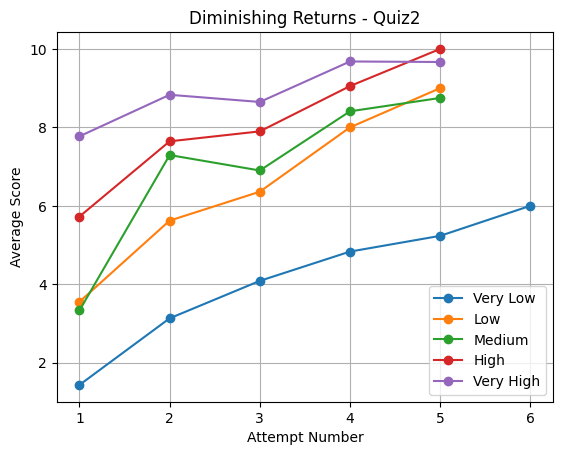

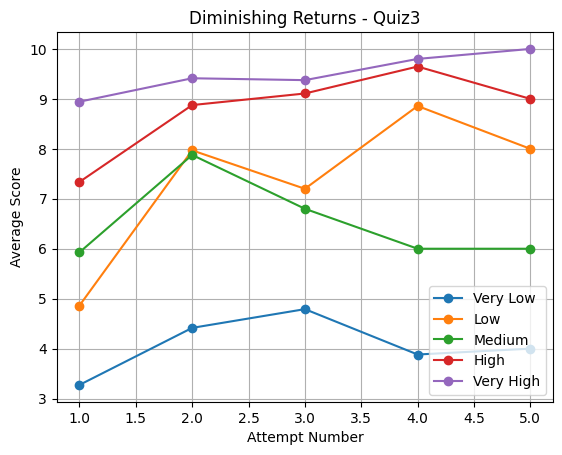

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

quizzes = df_clean['Quiz'].unique()

for quiz in quizzes:
    quiz_data = df_clean[df_clean['Quiz'] == quiz].copy()

    # 🔹 Compute final grade per student (ONLY for this quiz)
    student_final = quiz_data.groupby('Student Code')['Grade/10.00'].mean().reset_index()
    student_final.rename(columns={'Grade/10.00': 'FinalGrade'}, inplace=True)

    # 🔹 FIX: use rank to avoid duplicate bin edges
    student_final['Rank'] = student_final['FinalGrade'].rank(method='first')

    student_final['Group'] = pd.qcut(
    student_final['Rank'],
    5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

    # 🔹 Merge back
    quiz_data = quiz_data.merge(student_final[['Student Code', 'Group']],
                                on='Student Code', how='left')

    # 🔹 Plot
    plt.figure()

    groups = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

    for group in groups:
        group_data = quiz_data[quiz_data['Group'] == group]

        avg_scores = group_data.groupby('Attempt')['Grade/10.00'].mean().reset_index()

        plt.plot(avg_scores['Attempt'], avg_scores['Grade/10.00'], marker='o', label=group)

    plt.title(f'Diminishing Returns - {quiz}')
    plt.xlabel('Attempt Number')
    plt.ylabel('Average Score')
    plt.legend()
    plt.grid()

    plt.show()